# Preprocessing Validation

This notebook validates the preprocessing pipeline output: filtering,
resampling, and capacity grid computation for all NASA PCoE cells.

In [1]:
import sys
sys.path.insert(0, "..")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing.data_loader import load_all_nasa_cells

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

with open("../data/processed/processed_cells.pkl", "rb") as f:
    processed = pickle.load(f)

raw_cells = load_all_nasa_cells("../data/raw/nasa_pcoe")
print(f"Loaded {len(processed)} processed cells")

Loaded 4 processed cells


## 1. Filtering Validation

Overlay raw vs. filtered voltage for three discharge cycles per cell
(early, mid, late) to verify the Savitzky-Golay filter does not
significantly distort the voltage plateau.

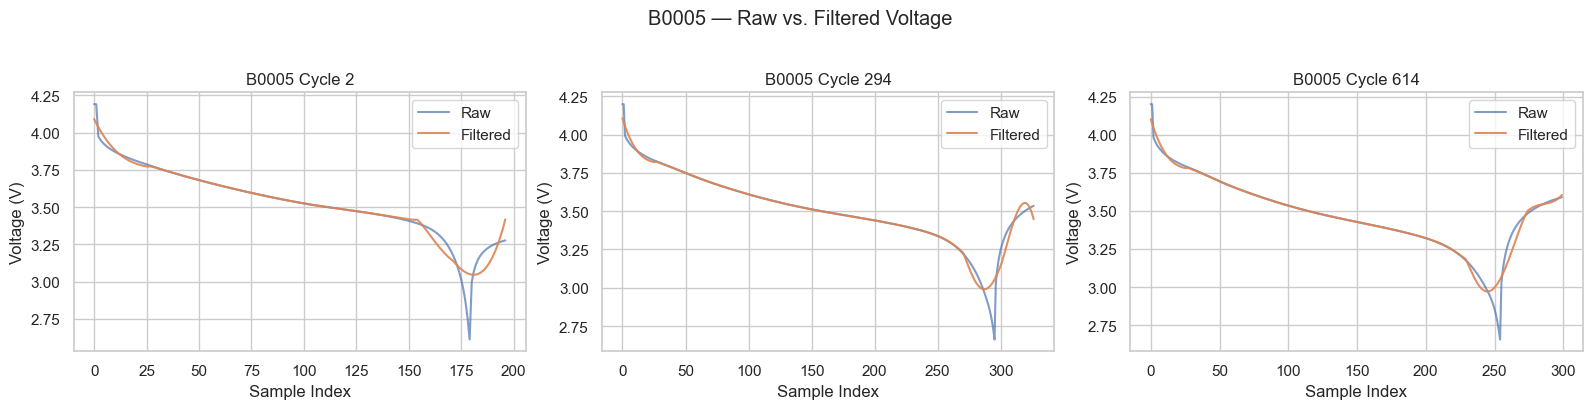

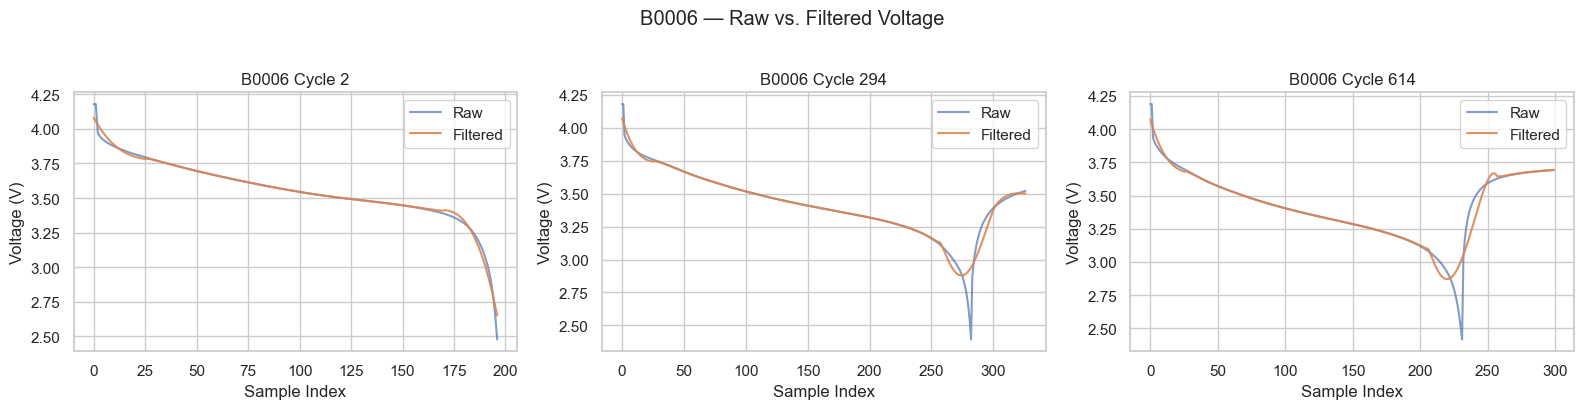

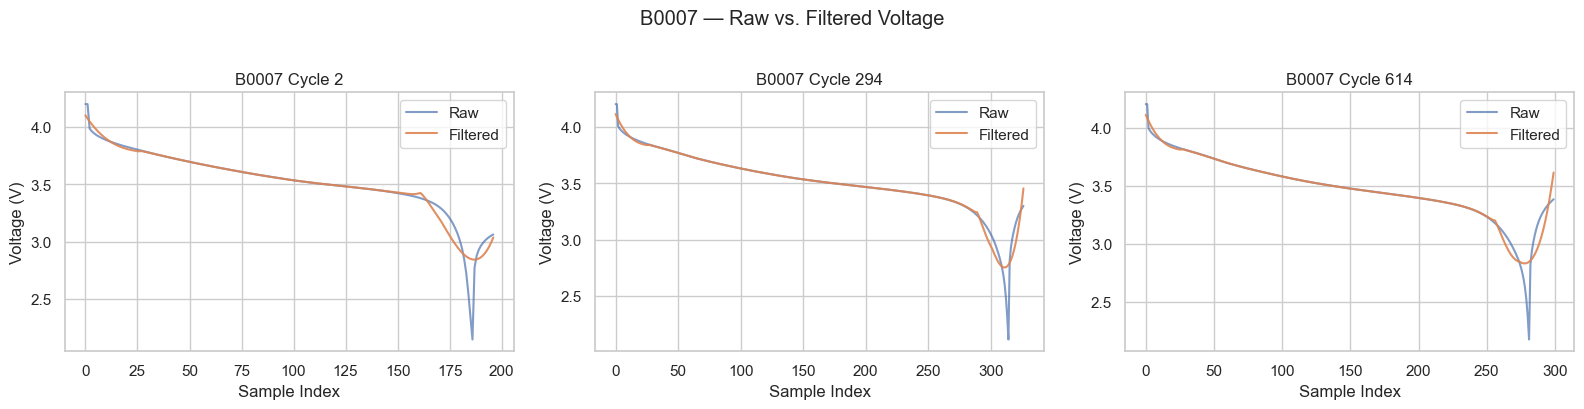

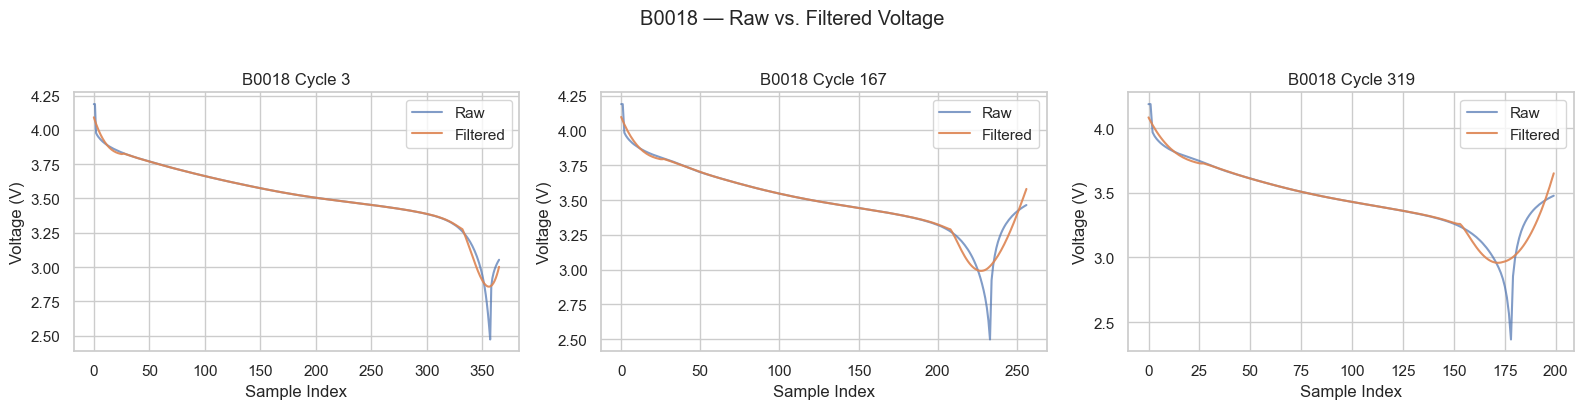

In [2]:
for cell_id in processed:
    discharge = [c for c in processed[cell_id]["cycles"] if c["type"] == "discharge"]
    n = len(discharge)
    indices = [0, n // 2, n - 1]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, idx in zip(axes, indices):
        c = discharge[idx]
        ax.plot(c["voltage"], label="Raw", alpha=0.7)
        ax.plot(c["voltage_filtered"], label="Filtered", alpha=0.9)
        ax.set_title(f"{cell_id} Cycle {c['cycle_number']}")
        ax.set_xlabel("Sample Index")
        ax.set_ylabel("Voltage (V)")
        ax.legend()

    fig.suptitle(f"{cell_id} — Raw vs. Filtered Voltage", y=1.02)
    plt.tight_layout()
    plt.show()

## 2. Resampling Validation

Check that resampled curves preserve the shape of the original
voltage-capacity curves. Plot original voltage vs. cumulative
capacity alongside the resampled version.

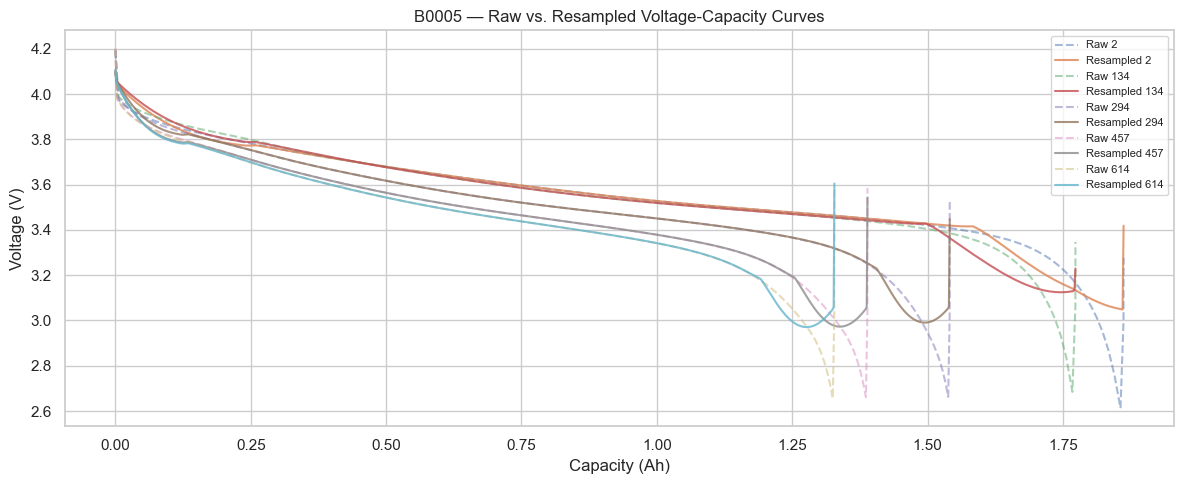

In [3]:
cell_id = "B0005"
discharge = [c for c in processed[cell_id]["cycles"] if c["type"] == "discharge"]
n = len(discharge)
indices = [0, n // 4, n // 2, 3 * n // 4, n - 1]

fig, ax = plt.subplots()
for idx in indices:
    c = discharge[idx]
    ax.plot(c["cumulative_capacity"], c["voltage"], "--", alpha=0.5, label=f"Raw {c['cycle_number']}")
    ax.plot(c["capacity_grid"], c["voltage_resampled"], "-", alpha=0.8, label=f"Resampled {c['cycle_number']}")

ax.set_xlabel("Capacity (Ah)")
ax.set_ylabel("Voltage (V)")
ax.set_title(f"{cell_id} — Raw vs. Resampled Voltage-Capacity Curves")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Capacity Grid Check

Verify all resampled cycles span [0, Q_measured] and that the
grid is uniform.

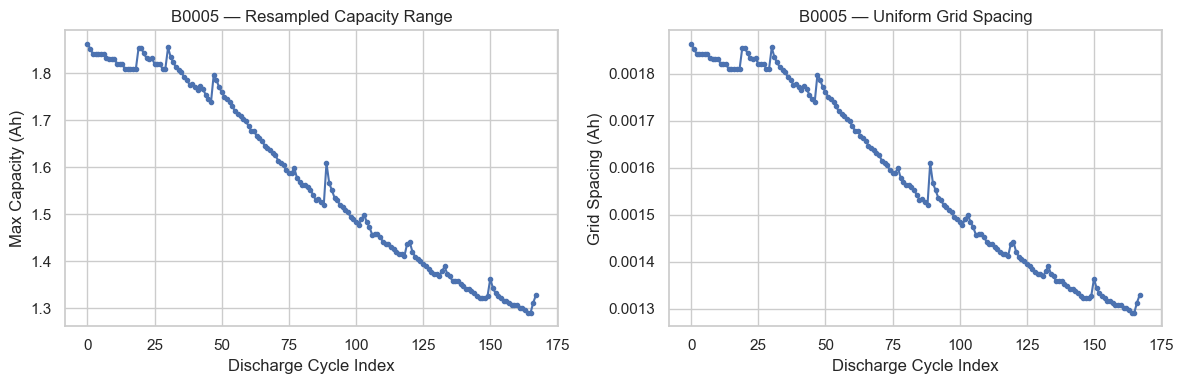

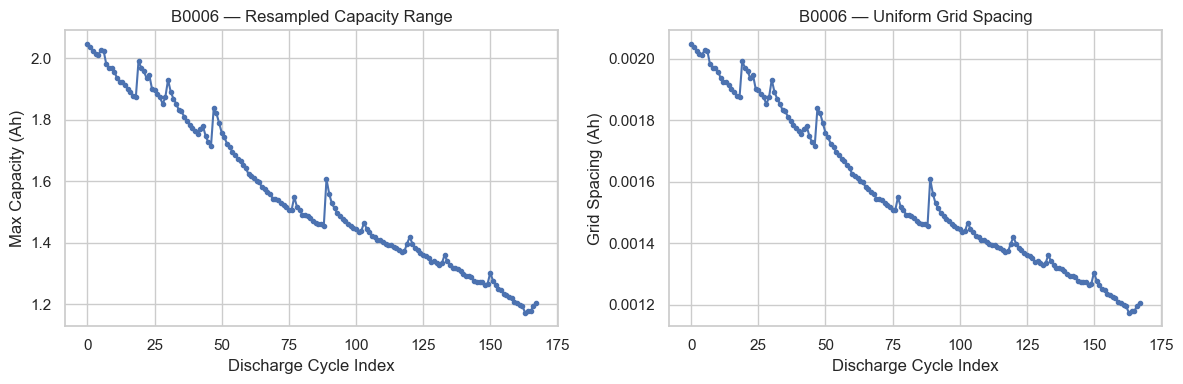

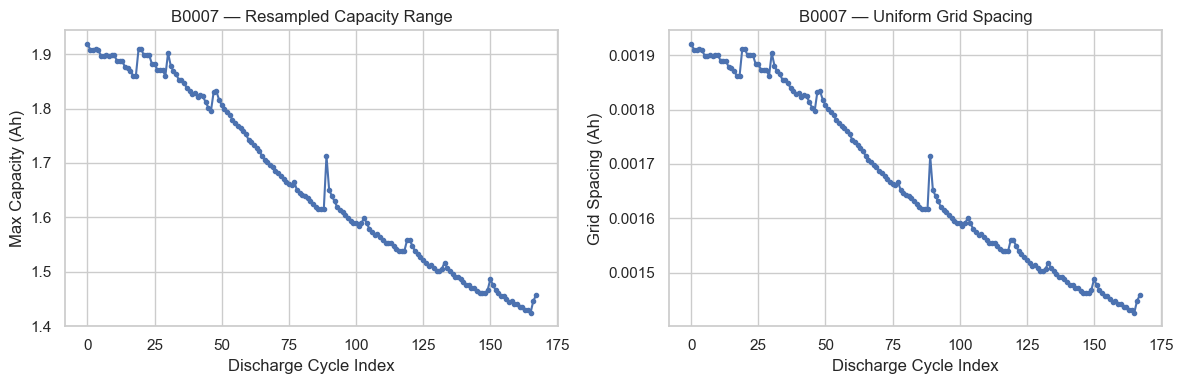

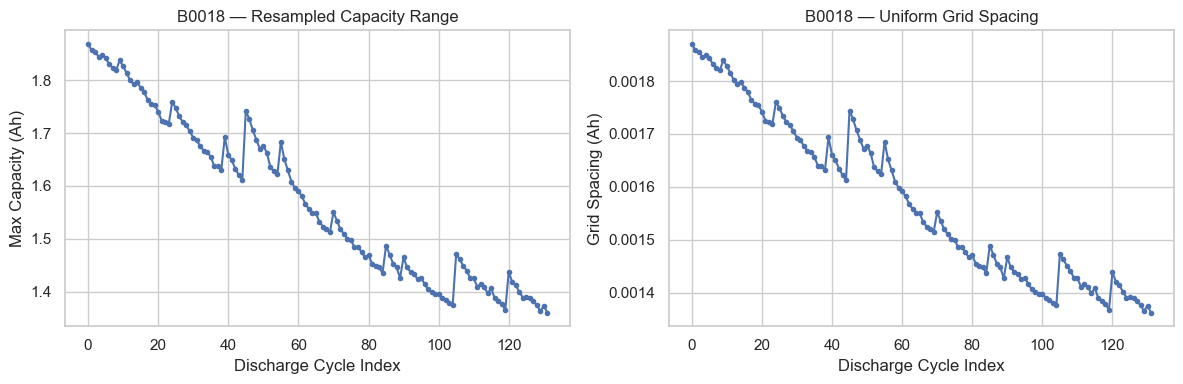

In [4]:
for cell_id in processed:
    discharge = [c for c in processed[cell_id]["cycles"] if c["type"] == "discharge"]
    cap_maxs = [c["capacity_grid"][-1] for c in discharge]
    grid_spacings = [np.diff(c["capacity_grid"]).mean() for c in discharge]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(cap_maxs, "o-", markersize=3)
    axes[0].set_xlabel("Discharge Cycle Index")
    axes[0].set_ylabel("Max Capacity (Ah)")
    axes[0].set_title(f"{cell_id} — Resampled Capacity Range")

    axes[1].plot(grid_spacings, "o-", markersize=3)
    axes[1].set_xlabel("Discharge Cycle Index")
    axes[1].set_ylabel("Grid Spacing (Ah)")
    axes[1].set_title(f"{cell_id} — Uniform Grid Spacing")

    plt.tight_layout()
    plt.show()

## 4. Cross-Cell Comparison

Plot resampled discharge voltage curves for all 4 cells to compare
their degradation trajectories.

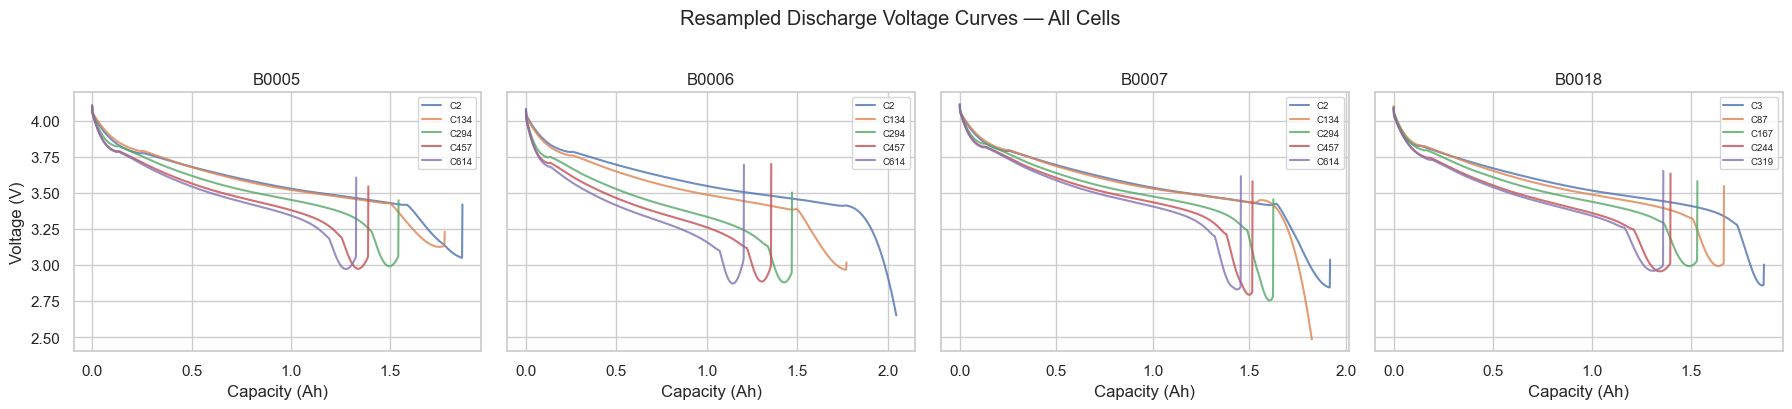

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for ax, cell_id in zip(axes, processed):
    discharge = [c for c in processed[cell_id]["cycles"] if c["type"] == "discharge"]
    n = len(discharge)
    sample_indices = [0, n // 4, n // 2, 3 * n // 4, n - 1]

    for idx in sample_indices:
        c = discharge[idx]
        label = f"C{c['cycle_number']}"
        ax.plot(c["capacity_grid"], c["voltage_resampled"], label=label, alpha=0.8)

    ax.set_xlabel("Capacity (Ah)")
    ax.set_title(cell_id)
    ax.legend(fontsize=7)

axes[0].set_ylabel("Voltage (V)")
fig.suptitle("Resampled Discharge Voltage Curves — All Cells", y=1.02)
plt.tight_layout()
plt.show()

## 5. Charge Cycle Preprocessing

Validate filtering on charge cycles, which are needed for ICA
(dQ/dV) computation.

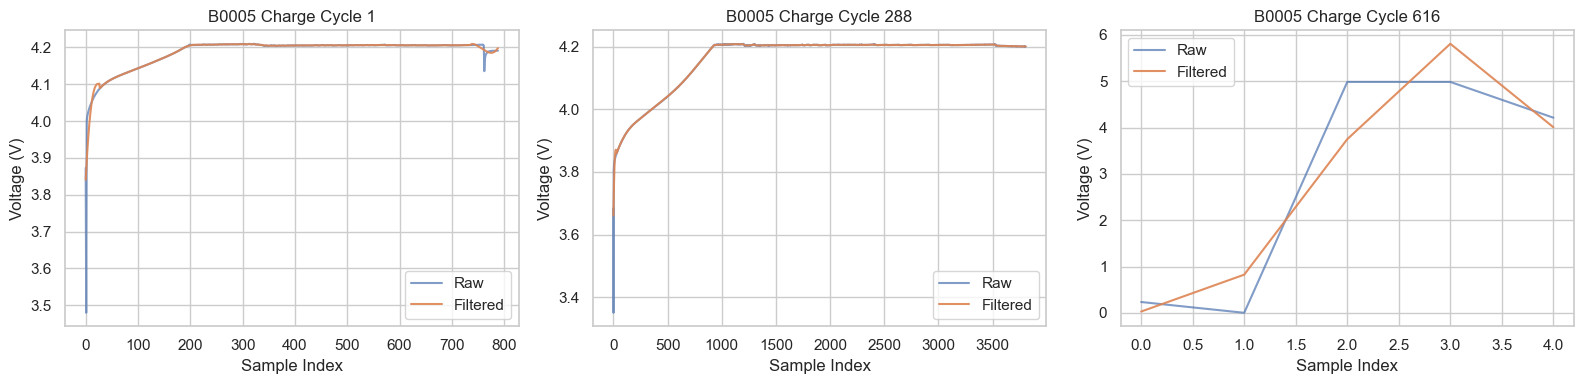

In [6]:
cell_id = "B0005"
charge = [c for c in processed[cell_id]["cycles"] if c["type"] == "charge"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, idx in zip(axes, [0, len(charge) // 2, -1]):
    c = charge[idx]
    if "voltage_filtered" in c:
        ax.plot(c["voltage"], label="Raw", alpha=0.7)
        ax.plot(c["voltage_filtered"], label="Filtered", alpha=0.9)
    ax.set_title(f"{cell_id} Charge Cycle {c['cycle_number']}")
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("Voltage (V)")
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Partial Cycle Check

Report how many cycles were kept vs. discarded by the validation step.

In [7]:
soh_df = pd.read_parquet("../data/processed/soh_labels.parquet")
print("SOH Labels Summary:")
print(soh_df.groupby("cell_id").agg(
    n_cycles=("cycle_number", "count"),
    soh_min=("soh", "min"),
    soh_max=("soh", "max"),
    soh_mean=("soh", "mean"),
).to_string())

SOH Labels Summary:
         n_cycles   soh_min  soh_max  soh_mean
cell_id                                       
B0005         168  0.700503      1.0  0.855406
B0006         168  0.573164      1.0  0.768298
B0007         168  0.744772      1.0  0.874457
B0018         132  0.725245      1.0  0.842386


## 7. Summary

**Key observations:**
- All 4 cells processed successfully with 1000-point uniform capacity grids
- Savitzky-Golay filtering smooths noise while preserving voltage plateau shape
- No partial cycles were discarded (all NASA cycles are complete)
- Resampled curves faithfully reproduce the original voltage-capacity shape
- Charge cycles also preprocessed for downstream ICA computation